# Titanic Wrangling

In this practice activity you'll continue to work with the titanic dataset in ways that flex what you've learned about both data wrangling and data visualization.

In [1]:
import numpy as np
import pandas as pd

In [2]:
data_dir = "https://dlsun.github.io/pods/data/"
df_titanic = pd.read_csv(data_dir + "titanic.csv")

## 1. Filter the data to include passengers only. Calculate the joint distribution (cross-tab) between a passenger's class and where they embarked.

In [3]:
# filter
df_titanic_pass = df_titanic[(df_titanic["class"] == "1st") | (df_titanic["class"] == "2nd") | (df_titanic["class"] == "3rd")]
# crosstab
pd.crosstab(df_titanic_pass["embarked"], df_titanic_pass["class"])

class,1st,2nd,3rd
embarked,,,
B,3,6,0
C,143,26,102
Q,3,7,113
S,175,245,494


## 2. Using the joint distribution that calculated above, calculate the following:

* the conditional distribution of their class given where they embarked
* the conditional distribution of where they embarked given their class

Use the conditional distributions that you calculate to answer the following quesitons:

* What proportion of 3rd class passengers embarked at Southampton?
* What proportion of Southampton passengers were in 3rd class?

In [4]:
# conditional distribution of class given embarked
pd.crosstab(df_titanic_pass["embarked"], df_titanic_pass["class"], normalize="index")

# alternative:
#df_titanic_pass.groupby("embarked")["class"].value_counts(nomralize=True)

class,1st,2nd,3rd
embarked,,,
B,0.333333,0.666667,0.000000
C,0.527675,0.095941,0.376384
Q,0.024390,0.056911,0.918699
S,0.191466,0.268053,0.540481


In [5]:
# conditional distribution of embarked given class
pd.crosstab(df_titanic_pass["class"], df_titanic_pass["embarked"], normalize="index")

embarked,B,C,Q,S
class,,,,
1st,0.009259,0.441358,0.009259,0.540123
2nd,0.021127,0.091549,0.024648,0.862676
3rd,0.000000,0.143865,0.159379,0.696756


The proportion of 3rd class passengers embarked at Southampton is 0.696756.

The proportion of Southampton passengers were in 3rd class is 0.540481.

## 3. Make a visualization showing the distribution of a passenger's class, given where they embarked.

Discuss the pros and cons of using this visualization versus the distributions you calculated before, to answer the previous questions.

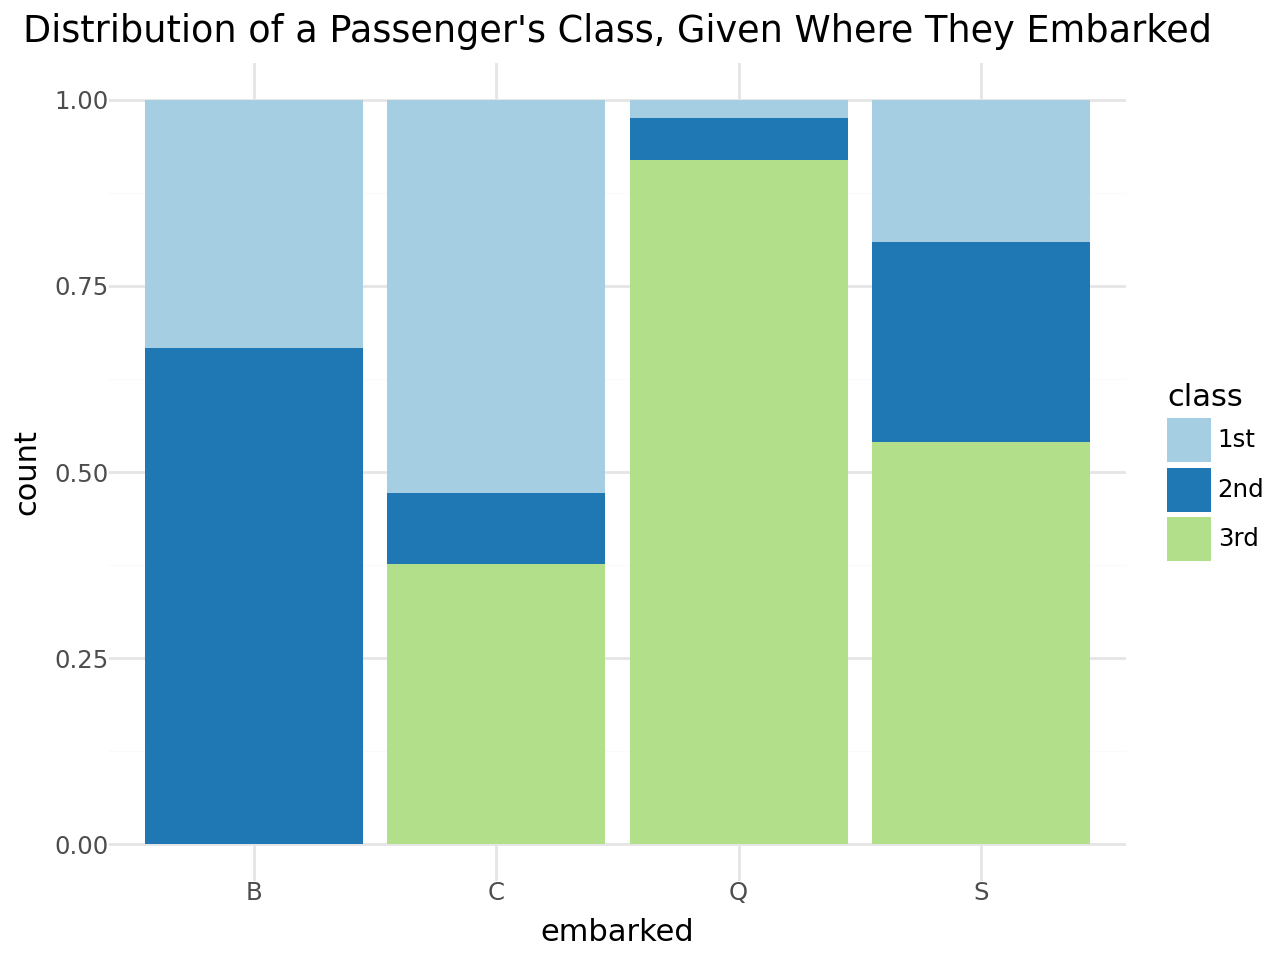

In [8]:
from plotnine import *

(ggplot(df_titanic_pass,
aes(
  x = "embarked",
  fill = "class"
))
+ geom_bar(position = "fill")
+ labs(title= "Distribution of a Passenger's Class, Given Where They Embarked")
+ theme_minimal()
+ scale_fill_brewer(type = 'qual', palette='Paired')
)